## Initial Portfolio Optimization & Sharpe Ratio

In [57]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.optimize import minimize

In [ ]:
tickers = ["0883.HK", "1088.HK", "0941.HK", "0939.HK", "1038.HK", "0002.HK"] # Just example stock tickers, can be changed according to your need
data = yf.download(tickers, start="2023-01-01", end="2026-01-01")['Close']
returns = data.pct_change().dropna().to_numpy()

[*********************100%***********************]  6 of 6 completed


In [59]:
mean_returns = np.mean(returns, axis=0) * 252
cov_matrix = np.cov(returns, rowvar=False) * 252
risk_free_rate = 0.03275 # 10 year bond yield taken from https://tradingeconomics.com/hong-kong/government-bond-yield 
num_assets = len(tickers)

In [60]:
def negative_sharpe(weights):
    p_return = np.dot(weights, mean_returns)
    p_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
    p_risk = np.sqrt(p_variance)
    sharpe = (p_return - risk_free_rate) / p_risk
    return -sharpe

In [61]:
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0, 1) for i in range(num_assets))
initial_guess = num_assets * [1.0 / num_assets]

In [62]:
optimized_result = minimize(
    fun=negative_sharpe, 
    x0=initial_guess, 
    method='SLSQP', 
    bounds=bounds, 
    constraints=constraints
)

In [63]:
best_weights = optimized_result.x
max_sharpe = -optimized_result.fun  

print("--- optimal portfolio found via scipy  ---")
for ticker, weight in zip(tickers, best_weights):
    print(f"{ticker} Exact Weight: {weight:.2%}")
print(f"Maximized Sharpe Ratio: {max_sharpe:.4f}")

--- optimal portfolio found via scipy  ---
0883.HK Exact Weight: 0.00%
1088.HK Exact Weight: 22.31%
0941.HK Exact Weight: 11.44%
0939.HK Exact Weight: 31.99%
1038.HK Exact Weight: 23.56%
0002.HK Exact Weight: 10.70%
Maximized Sharpe Ratio: 1.4754


## Efficient Frontier (Monte Carlo)
Simulate random portfolios and visualize the risk-return trade-off. The red star is the max-Sharpe portfolio from the optimizer.

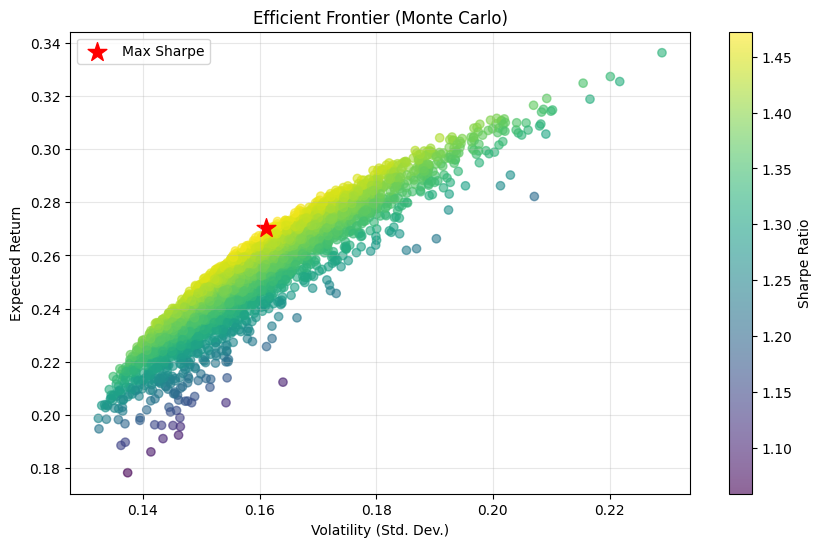

In [65]:
import matplotlib.pyplot as plt

def portfolio_perf(weights):
    p_return = np.dot(weights, mean_returns)
    p_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
    p_risk = np.sqrt(p_variance)
    return p_return, p_risk

num_portfolios = 4000
rng = np.random.default_rng()
random_weights = rng.random((num_portfolios, num_assets))
random_weights /= random_weights.sum(axis=1, keepdims=True)

portfolio_returns = random_weights @ mean_returns
portfolio_vols = np.sqrt(np.einsum("ij,jk,ik->i", random_weights, cov_matrix, random_weights))
portfolio_sharpes = (portfolio_returns - risk_free_rate) / portfolio_vols

plt.figure(figsize=(10, 6))
scatter = plt.scatter(portfolio_vols, portfolio_returns, c=portfolio_sharpes, cmap="viridis", alpha=0.6)
plt.colorbar(scatter, label="Sharpe Ratio")

best_return, best_risk = portfolio_perf(best_weights)
plt.scatter([best_risk], [best_return], color="red", marker="*", s=200, label="Max Sharpe")

plt.title("Efficient Frontier (Monte Carlo)")
plt.xlabel("Volatility (Std. Dev.)")
plt.ylabel("Expected Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()